In [1]:
!wget -nc http://lazyprogrammer.me/course_files/AirlineTweets.csv

--2026-03-26 17:01:39--  http://lazyprogrammer.me/course_files/AirlineTweets.csv
Resolving lazyprogrammer.me (lazyprogrammer.me)... 104.21.23.210, 172.67.213.166, 2606:4700:3031::6815:17d2, ...
Connecting to lazyprogrammer.me (lazyprogrammer.me)|104.21.23.210|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://lazyprogrammer.me/course_files/AirlineTweets.csv [following]
--2026-03-26 17:01:40--  https://lazyprogrammer.me/course_files/AirlineTweets.csv
Connecting to lazyprogrammer.me (lazyprogrammer.me)|104.21.23.210|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3421431 (3.3M) [text/csv]
Saving to: ‘AirlineTweets.csv’

AirlineTweets.csv   100%[===================>]   3.26M  --.-KB/s    in 0.1s    

2026-03-26 17:01:40 (23.5 MB/s) - ‘AirlineTweets.csv’ saved [3421431/3421431]



In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sn
import torch

from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split


In [3]:
df_ = pd.read_csv('AirlineTweets.csv')

In [4]:
df_.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [5]:
df = df_[['airline_sentiment', 'text']].copy()

In [6]:
df.head()

,airline_sentiment,text
0,neutral,@VirginAmerica What @dhepburn said.
1,positive,@VirginAmerica plus you've added commercials t...
2,neutral,@VirginAmerica I didn't today... Must mean I n...
3,negative,@VirginAmerica it's really aggressive to blast...
4,negative,@VirginAmerica and it's a really big bad thing...


<Axes: >

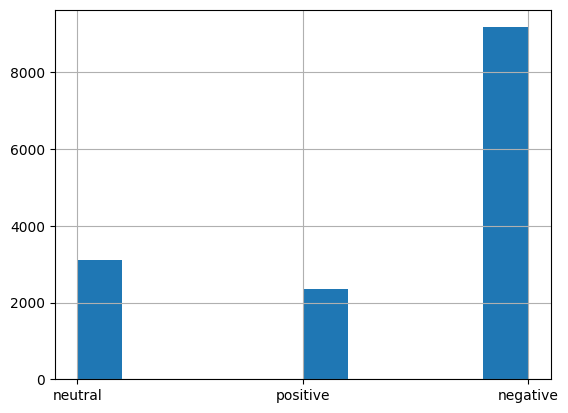

In [7]:
df['airline_sentiment'].hist()

In [8]:
target_map = {'positive': 1, 'negative': 0, 'neutral': 2}
df['target'] = df['airline_sentiment'].map(target_map)

In [9]:
df2 = df[['text', 'target']]
df2.columns = ['sentence', 'label']
df2.to_csv('data.csv', index=None)

In [10]:
!head data.csv

sentence,label
@VirginAmerica What @dhepburn said.,2
@VirginAmerica plus you've added commercials to the experience... tacky.,1
@VirginAmerica I didn't today... Must mean I need to take another trip!,2
"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have little recourse",0
@VirginAmerica and it's a really big bad thing about it,0
"@VirginAmerica seriously would pay $30 a flight for seats that didn't have this playing.
it's really the only bad thing about flying VA",0
"@VirginAmerica yes, nearly every time I fly VX this “ear worm” won’t go away :)",1
"@VirginAmerica Really missed a prime opportunity for Men Without Hats parody, there. https://t.co/mWpG7grEZP",2


In [11]:
from datasets import load_dataset
raw_dataset = load_dataset('csv', data_files='data.csv')

Generating train split: 0 examples [00:00, ? examples/s]

In [12]:
raw_dataset

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label'],
        num_rows: 14640
    })
})

In [13]:
split = raw_dataset['train'].train_test_split(test_size=0.3, seed=42)

In [14]:
split

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label'],
        num_rows: 10248
    })
    test: Dataset({
        features: ['sentence', 'label'],
        num_rows: 4392
    })
})

In [15]:
### for multiple csv files
### load_dataset('csv', data_files=['file1.csv', 'file2.csv'])

### if you have a train-test split already:
# load_dataset(
#   'csv'
#   data_files={'train': ['train1.csv', 'train2.csv'],
#               'test': 'test.csv'
#   }
# )

In [16]:
checkpoint = 'distilbert-base-cased'

In [17]:
from transformers import AutoTokenizer

In [18]:
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/465 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [19]:
def tokenize_fn(batch):
    return tokenizer(batch['sentence'], truncation=True)

In [20]:
tokenized_datasets = split.map(tokenize_fn, batched=True)

Map:   0%|          | 0/10248 [00:00<?, ? examples/s]

Map:   0%|          | 0/4392 [00:00<?, ? examples/s]

In [22]:
from transformers import AutoModelForSequenceClassification, AutoConfig, \
    Trainer, TrainingArguments

In [23]:
config = AutoConfig.from_pretrained(checkpoint)

In [24]:
config

DistilBertConfig {
  "activation": "gelu",
  "architectures": [
    "DistilBertForMaskedLM"
  ],
  "attention_dropout": 0.1,
  "bos_token_id": null,
  "dim": 768,
  "dropout": 0.1,
  "eos_token_id": null,
  "hidden_dim": 3072,
  "initializer_range": 0.02,
  "max_position_embeddings": 512,
  "model_type": "distilbert",
  "n_heads": 12,
  "n_layers": 6,
  "output_past": true,
  "pad_token_id": 0,
  "qa_dropout": 0.1,
  "seq_classif_dropout": 0.2,
  "sinusoidal_pos_embds": false,
  "tie_weights_": true,
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "vocab_size": 28996
}

In [26]:
dir(config)

['__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_attn_implementation',
 '_attn_implementation_internal',
 '_auto_class',
 '_check_received_keys',
 '_commit_hash',
 '_create_id_label_maps',
 '_decode_special_floats',
 '_dict_from_json_file',
 '_encode_special_floats',
 '_experts_implementation',
 '_experts_implementation_internal',
 '_get_config_dict',
 '_get_files_timestamps',
 '_get_generation_parameters',
 '_name_or_path',
 '_output_attentions',
 '_remove_keys_not_serialized',
 '_upload_modified_files',
 '_validate_default_rope_parameters',
 '_validate_dynamic_rope_parameters',
 '_validate_linear_rope_parameters',
 '

In [27]:
config.id2label

{0: 'LABEL_0', 1: 'LABEL_1'}

In [28]:
config.label2id

{'LABEL_0': 0, 'LABEL_1': 1}

In [30]:
target_map

{'positive': 1, 'negative': 0, 'neutral': 2}

In [29]:
config.id2label = {v:k for k,v in target_map.items()}
config.label2id = target_map

In [31]:
config.id2label

{1: 'positive', 0: 'negative', 2: 'neutral'}

In [32]:
config.label2id

{'positive': 1, 'negative': 0, 'neutral': 2}

In [33]:
model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint, config=config)

model.safetensors:   0%|          | 0.00/263M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [35]:
!pip install torchinfo

In [36]:
from torchinfo import summary

In [ ]:
summary(model)

Layer (type:depth-idx)                                  Param #
DistilBertForSequenceClassification                     --
├─DistilBertModel: 1-1                                  --
│    └─Embeddings: 2-1                                  --
│    │    └─Embedding: 3-1                              22,268,928
│    │    └─Embedding: 3-2                              393,216
│    │    └─LayerNorm: 3-3                              1,536
│    │    └─Dropout: 3-4                                --
│    └─Transformer: 2-2                                 --
│    │    └─ModuleList: 3-5                             42,527,232
├─Linear: 1-2                                           590,592
├─Linear: 1-3                                           2,307
├─Dropout: 1-4                                          --
Total params: 65,783,811
Trainable params: 65,783,811
Non-trainable params: 0

In [37]:
training_args = TrainingArguments(
    output_dir='training_dir',
    eval_strategy="epoch", # used to be evaluation_strategy, not anymore
    save_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
)

In [38]:
def compute_metrics(logits_and_labels):
    logits, labels = logits_and_labels
    predictions = np.argmax(logits, axis=-1)
    acc = np.mean(predictions == labels)
    f1 = f1_score(labels, predictions, average='macro')
    return {'accuracy': acc, 'f1': f1}

In [39]:
trainer = Trainer(
    model,
    training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['test'],
    processing_class=tokenizer, # new way to pass the tokenizer
    compute_metrics=compute_metrics,
)

In [40]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.537442,0.449120,0.830146,0.765035
2,0.343142,0.505936,0.832195,0.769545
3,0.236415,0.634109,0.828780,0.773590


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1923, training_loss=0.32441367845143493, metrics={'train_runtime': 218.2171, 'train_samples_per_second': 140.887, 'train_steps_per_second': 8.812, 'total_flos': 388537948763424.0, 'train_loss': 0.32441367845143493, 'epoch': 3.0})

In [41]:
!ls training_dir/

checkpoint-1282  checkpoint-1923  checkpoint-641


In [42]:
from transformers import pipeline

In [43]:
savedmodel = pipeline('text-classification',
                      model='training_dir/checkpoint-1282',
                      device=0
                      )

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [44]:
split['test']

Dataset({
    features: ['sentence', 'label'],
    num_rows: 4392
})

In [47]:
test_pred = savedmodel(list(split['test']['sentence']))

In [48]:
test_pred[0:5]

[{'label': 'positive', 'score': 0.9232540726661682},
 {'label': 'positive', 'score': 0.9400937557220459},
 {'label': 'negative', 'score': 0.7488986253738403},
 {'label': 'positive', 'score': 0.7978631854057312},
 {'label': 'neutral', 'score': 0.4047217071056366}]

In [53]:
# we stick to test_pred2 since that's the expected output
def get_label(d):
    return d['label']

test_pred = [get_label(d) for d in test_pred]

In [54]:
test_pred[0:5]

['positive', 'positive', 'negative', 'positive', 'neutral']

In [55]:
test_pred2 = [target_map[label] for label in test_pred]

In [56]:
test_pred2[0:5]

[1, 1, 0, 1, 2]

In [58]:
print("acc:", accuracy_score(split['test']['label'], test_pred2))

acc: 0.8321948998178507


In [59]:
print("f1:", f1_score(split['test']['label'], test_pred2, average='macro'))

f1: 0.7695448317991533


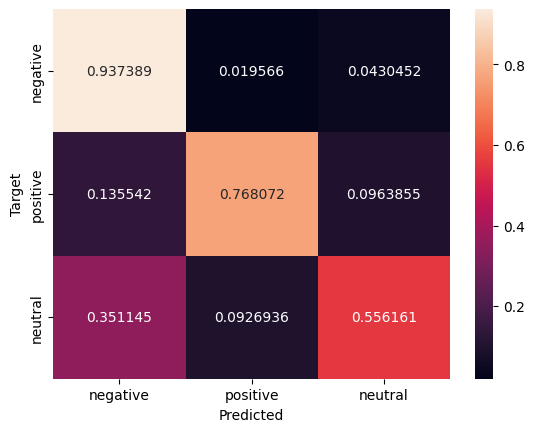

In [60]:
# old plotting code in case we don't have V1 of scikit-learn
def plot_cm(cm):
    classes = ['negative', 'positive', 'neutral']
    df_cm = pd.DataFrame(cm, index=classes, columns=classes)
    ax = sn.heatmap(df_cm, annot=True, fmt='g')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Target')

cm = confusion_matrix(split['test']['label'], test_pred2, normalize='true')
plot_cm(cm)